<a href="https://colab.research.google.com/github/gsantillan-coder/DL-Final-Santillan-Guido/blob/main/notebooks/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de necesidad de mantenimiento en sistemas de detección de gases mediante Deep Learning

## Introducción

Los sistemas de detección de gases son fundamentales para la seguridad en entornos industriales y mineros, ya que permiten monitorear continuamente la presencia de gases peligrosos.

Este proyecto propone el desarrollo de un modelo de Deep Learning capaz de predecir la necesidad de mantenimiento en detectores de gases a partir de variables operativas, ambientales e históricas.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
import pandas as pd

base_url = "https://raw.githubusercontent.com/gsantillan-coder/DL-Final-Santillan-Guido/main/data/"

files = [
    "batch1.dat","batch2.dat","batch3.dat","batch4.dat","batch5.dat",
    "batch6.dat","batch7.dat","batch8.dat","batch9.dat","batch10.dat"
]

dfs = []

for f in files:
    url = base_url + f
    df = pd.read_csv(url, sep=" ", header=None)
    df["batch"] = f
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data.head()

,0,1,2,3,4,5,6,7,8,9,...,120,121,122,123,124,125,126,127,128,batch
0,1,1:15596.162100,2:1.868245,3:2.371604,4:2.803678,5:7.512213,6:-2.739388,7:-3.344671,8:-4.847512,9:15326.691400,...,120:-3.037772,121:3037.039000,122:3.972203,123:0.527291,124:0.728443,125:1.445783,126:-0.545079,127:-0.902241,128:-2.654529,batch1.dat
1,1,1:26402.070400,2:2.532401,3:5.411209,4:6.509906,5:7.658469,6:-4.722217,7:-5.817651,8:-7.518333,9:23855.781200,...,120:-1.994993,121:4176.445300,122:4.281373,123:0.980205,124:1.628050,125:1.951172,126:-0.889333,127:-1.323505,128:-1.749225,batch1.dat
2,1,1:42103.582000,2:3.454189,3:8.198175,4:10.508439,5:11.611003,6:-7.668313,7:-9.478675,8:-12.230939,9:37562.300800,...,120:-2.867291,121:5914.668500,122:5.396827,123:1.403973,124:2.476956,125:3.039841,126:-1.334558,127:-1.993659,128:-2.348370,batch1.dat
3,1,1:42825.988300,2:3.451192,3:12.113940,4:16.266853,5:39.910056,6:-7.849409,7:-9.689894,8:-11.921704,9:38379.066400,...,120:-3.058086,121:6147.474400,122:5.501071,123:1.981933,124:3.569823,125:4.049197,126:-1.432205,127:-2.146158,128:-2.488957,batch1.dat
4,1,1:58151.175700,2:4.194839,3:11.455096,4:15.715298,5:17.654915,6:-11.083364,7:-13.580692,8:-16.407848,9:51975.589900,...,120:-4.181920,121:8158.644900,122:7.174334,123:1.993808,124:3.829303,125:4.402448,126:-1.930107,127:-2.931265,128:-4.088756,batch1.dat


In [ ]:
data.shape

(13910, 130)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Columns: 130 entries, 0 to batch
dtypes: int64(1), object(129)
memory usage: 13.8+ MB


In [ ]:
# eliminar el número del sensor y dejar solo el valor
for col in data.columns[:-1]:   # excluye la columna batch
    data[col] = data[col].astype(str).str.split(":").str[-1]

# convertir todo a número
data.iloc[:, :-1] = data.iloc[:, :-1].apply(pd.to_numeric)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Columns: 130 entries, 0 to batch
dtypes: object(130)
memory usage: 13.8+ MB


In [ ]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,120,121,122,123,124,125,126,127,128,batch
0,1,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,15326.6914,...,-3.037772,3037.039,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529,batch1.dat
1,1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,23855.7812,...,-1.994993,4176.4453,4.281373,0.980205,1.62805,1.951172,-0.889333,-1.323505,-1.749225,batch1.dat
2,1,42103.582,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,37562.3008,...,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.34837,batch1.dat
3,1,42825.9883,3.451192,12.11394,16.266853,39.910056,-7.849409,-9.689894,-11.921704,38379.0664,...,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957,batch1.dat
4,1,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,-16.407848,51975.5899,...,-4.18192,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756,batch1.dat


In [ ]:
# convertir todas las columnas excepto 'batch' a numéricas
for col in data.columns:
    if col != "batch":
        data[col] = pd.to_numeric(data[col], errors="coerce")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Columns: 130 entries, 0 to batch
dtypes: float64(128), int64(1), object(1)
memory usage: 13.8+ MB


### Crear Variable Objetivo

In [ ]:
data["drift"] = data["batch"].apply(
    lambda x: 0 if int(x.replace("batch","").replace(".dat","")) <= 5 else 1
)

/tmp/ipykernel_423/2839719925.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["drift"] = data["batch"].apply(


In [ ]:
data["drift"].value_counts()

,count
drift,
1,10277
0,3633


### Separar las variables X e y

In [ ]:
X = data.drop(columns=["batch","drift"])
y = data["drift"]

### Gráfico de distribución de la variable objetivo


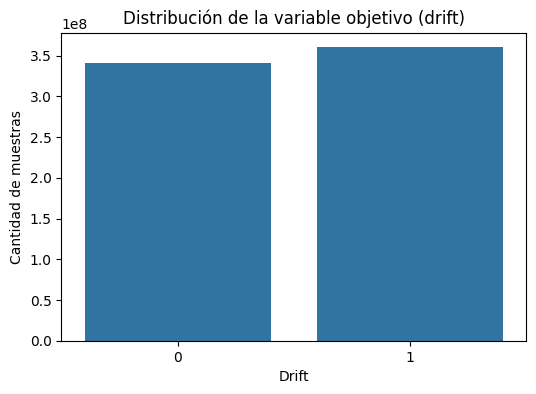

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="drift", data=data)
plt.title("Distribución de la variable objetivo (drift)")
plt.xlabel("Drift")
plt.ylabel("Cantidad de muestras")
plt.show()

### Boxplot de algunas variables por clase

Para mostrar diferencias entre sensores con y sin drift.

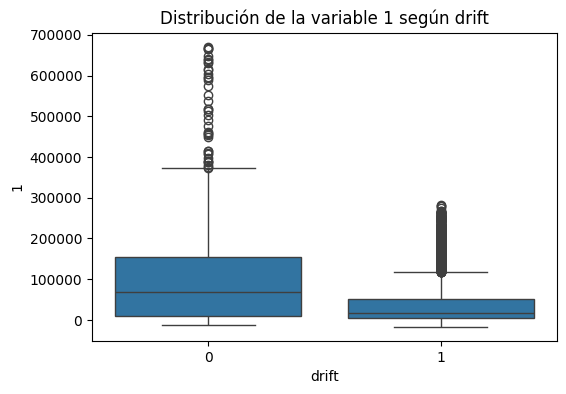

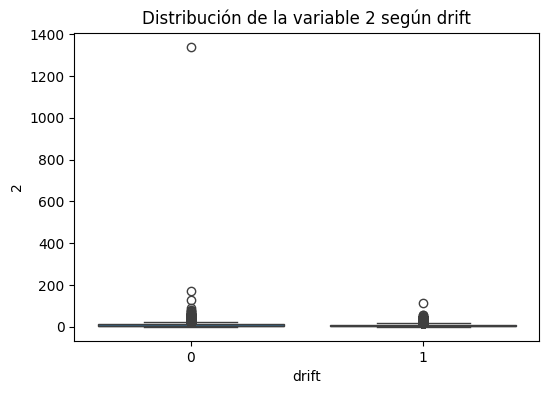

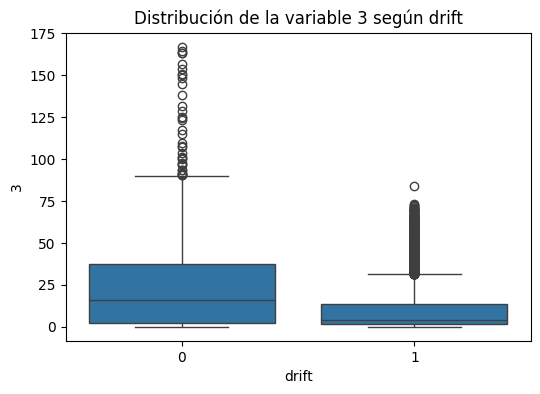

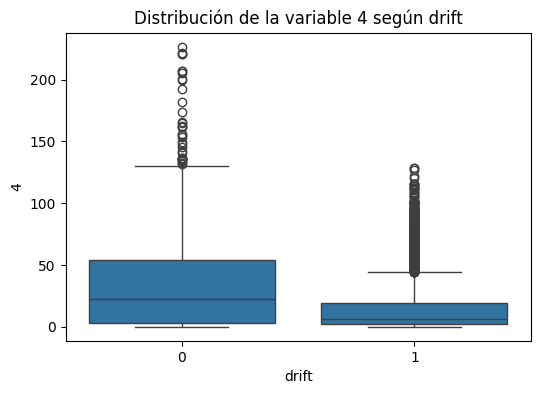

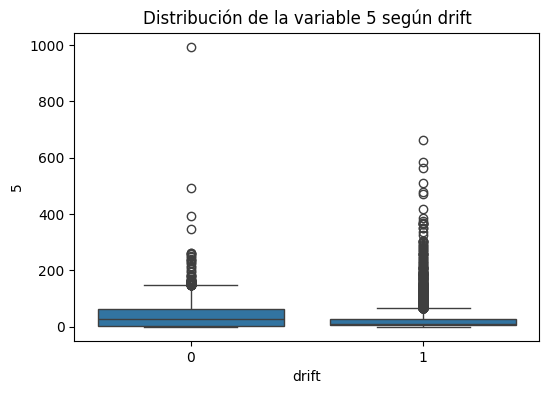

In [ ]:
selected_cols = [1, 2, 3, 4, 5]

for col in selected_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="drift", y=col, data=data)
    plt.title(f"Distribución de la variable {col} según drift")
    plt.show()

### Heatmap de correlación

Para justificar relaciones entre variables.

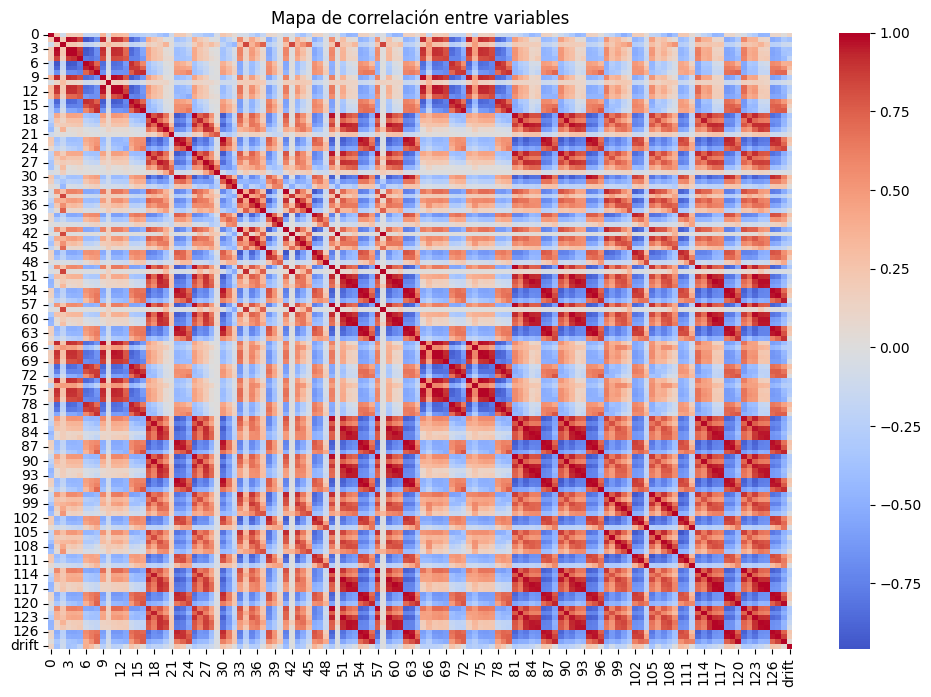

In [ ]:
plt.figure(figsize=(12,8))
corr = data.drop(columns=["batch"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Mapa de correlación entre variables")
plt.show()

### PCA en 2D

Este te ayudaría mucho visualmente en el video.

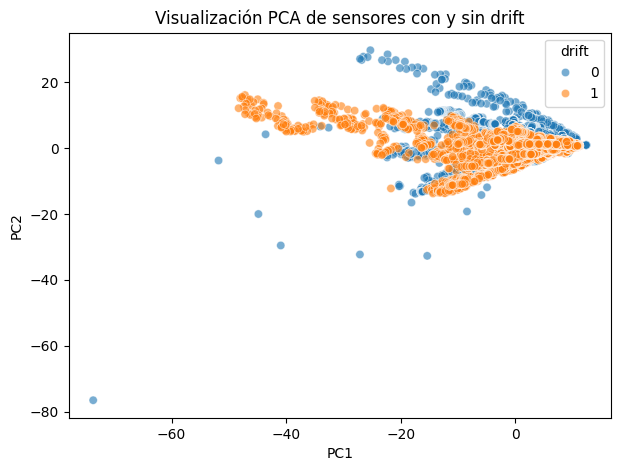

In [ ]:
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(data.drop(columns=["batch", "drift"]))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["drift"] = data["drift"].values

plt.figure(figsize=(7,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="drift", alpha=0.6)
plt.title("Visualización PCA de sensores con y sin drift")
plt.show()

### Train / Test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Escalar Variables

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Construir la red neuronal

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,009 (105.50 KB)

 Trainable params: 27,009 (105.50 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el Modelo

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9399 - loss: 0.1998 - val_accuracy: 0.9942 - val_loss: 0.0296
Epoch 2/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9931 - loss: 0.0380 - val_accuracy: 0.9933 - val_loss: 0.0224
Epoch 3/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9939 - loss: 0.0182 - val_accuracy: 0.9969 - val_loss: 0.0114
Epoch 4/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9951 - loss: 0.0240 - val_accuracy: 0.9987 - val_loss: 0.0081
Epoch 5/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9971 - loss: 0.0147 - val_accuracy: 0.9969 - val_loss: 0.0127
Epoch 6/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9982 - loss: 0.0067 - val_accuracy: 0.9987 - val_loss: 0.0053
Epoch 7/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 0.9982 - val_loss: 0.0067
Epoch 8/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9954 - loss: 0.0137 - val_accuracy: 0.

### Evaluar modelo

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9989 - loss: 0.1067  
Accuracy: 0.9989216327667236


### Matriz de confusión + ROC AUC


87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


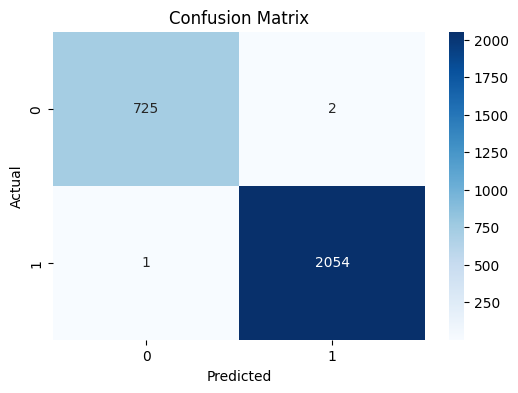

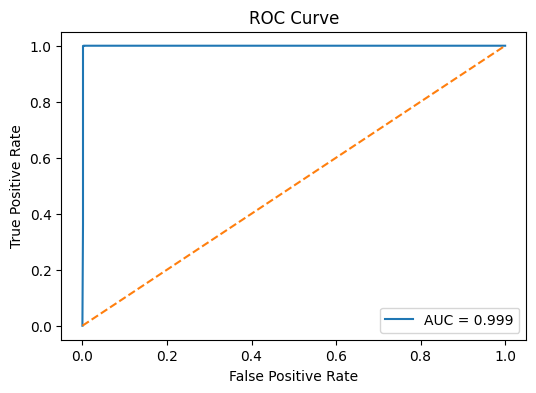

ROC AUC: 0.9988


In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predicciones
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"ROC AUC: {auc_score:.4f}")

### Gráficas de entrenamiento

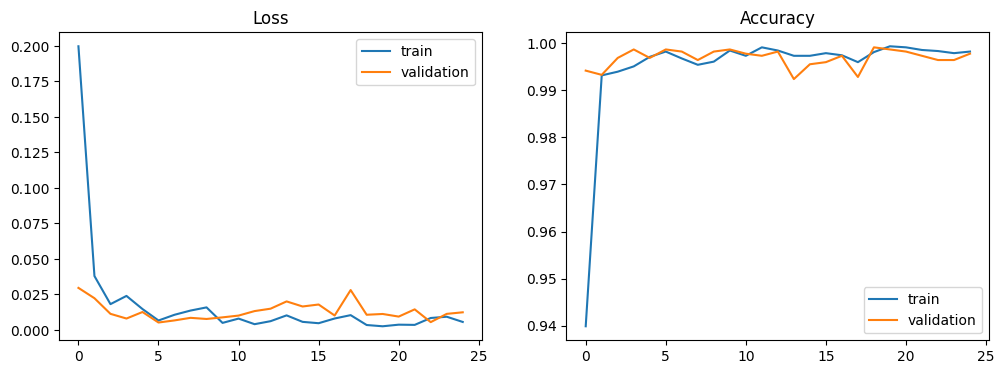

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       727
           1       1.00      1.00      1.00      2055

    accuracy                           1.00      2782
   macro avg       1.00      1.00      1.00      2782
weighted avg       1.00      1.00      1.00      2782



### Conclusiones

- Se ha desarrollado un modelo de Deep Learning capaz de predecir la necesidad de mantenimiento en detectores de gases con una alta precisión.
- Los gráficos de entrenamiento muestran una convergencia rápida y una buena performance tanto en el conjunto de entrenamiento como en el de validación.
- La matriz de confusión y la curva ROC AUC confirman la solidez del modelo en la clasificación de instancias con y sin 'drift'.
- Es importante destacar la relevancia de los pasos de preprocesamiento de datos, como la estandarización y la creación de la variable objetivo, para el éxito del modelo.
- Futuras mejoras podrían incluir la exploración de arquitecturas de red más complejas o la incorporación de más datos para generalizar aún más el modelo.